# 03 - Visualización de Entrenamiento de Modelos

Este notebook analiza los artefactos generados por el proceso de entrenamiento y optimización de modelos para predicción cardiovascular.

Resultados incluidos:
- Evolución de trials de Optuna por modelo.
- Comparación de métricas en validación.
- Matrices de confusión por modelo.
- Curvas ROC por modelo.
- Ranking final en validación y evaluación en test.

Criterio de interpretación:
- La selección principal se basa en ROC-AUC y F1-score en validación.
- La evaluación en test se utiliza como estimación final de generalización.

In [14]:
from pathlib import Path
import re
import json

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_curve,
    auc,
 )

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 10

MODEL_NAMES = {
    "LR": "Regresión Logística",
    "RF": "Random Forest",
    "XGB": "XGBoost",
    "LGBM": "LightGBM",
}

In [15]:
start_path = Path.cwd().resolve()
candidate_roots = [start_path, *start_path.parents]

PROJECT_ROOT = None
for root in candidate_roots:
    if (root / "models").exists() and (root / "notebooks").exists():
        PROJECT_ROOT = root
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "No se encontró la raíz del proyecto. Abra el notebook dentro del workspace Prediccion_Cardiovascular."
    )

MODELS_DIR = PROJECT_ROOT / "models"

# Soporta ambos patrones: Experimento1 y Experimento_1
exp_pattern = re.compile(r"^Experimento_?(\d+)$")
experiments = []
for item in MODELS_DIR.iterdir() if MODELS_DIR.exists() else []:
    if item.is_dir():
        m = exp_pattern.match(item.name)
        if m:
            experiments.append((int(m.group(1)), item))

if experiments:
    latest_exp_number, latest_exp_path = sorted(experiments, key=lambda x: x[0])[-1]
    MODELS_SOURCE_DIR = latest_exp_path
    ARTIFACTS_DIR = latest_exp_path / "training_artifacts"
    source_desc = f"{latest_exp_path.name}"
else:
    latest_exp_number = None
    latest_exp_path = None
    MODELS_SOURCE_DIR = MODELS_DIR
    ARTIFACTS_DIR = MODELS_DIR / "training_artifacts"
    source_desc = "models/ (sin carpeta de experimento)"

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Fuente de modelos: {source_desc}")
print(f"Carpeta de modelos: {MODELS_SOURCE_DIR}")
print(f"Carpeta de artefactos: {ARTIFACTS_DIR} {'(no encontrada)' if not ARTIFACTS_DIR.exists() else ''}")

Proyecto: C:\Users\LENOVO\Documents\Jhandry U\Prediccion_Cardiovascular
Fuente de modelos: Experimento11
Carpeta de modelos: C:\Users\LENOVO\Documents\Jhandry U\Prediccion_Cardiovascular\models\Experimento11
Carpeta de artefactos: C:\Users\LENOVO\Documents\Jhandry U\Prediccion_Cardiovascular\models\Experimento11\training_artifacts 


In [16]:
models = ["LR", "RF", "XGB", "LGBM"]

metrics_rows = []
trials_data = {}
preds_data = {}
overfit_data = {}
problematic_data = {}

for model in models:
    metrics_path = ARTIFACTS_DIR / f"val_metrics_{model}.csv"
    trials_path = ARTIFACTS_DIR / f"optuna_trials_{model}.csv"
    preds_path = ARTIFACTS_DIR / f"val_predictions_{model}.csv"
    overfit_path = ARTIFACTS_DIR / f"overfitting_diagnostics_{model}.json"
    problematic_path = ARTIFACTS_DIR / f"problematic_validation_samples_{model}.csv"

    if metrics_path.exists():
        mdf = pd.read_csv(metrics_path)
        mdf["model_name"] = mdf["model"].map(MODEL_NAMES).fillna(mdf["model"])
        metrics_rows.append(mdf)

    if trials_path.exists():
        trials_data[model] = pd.read_csv(trials_path)

    if preds_path.exists():
        preds_data[model] = pd.read_csv(preds_path)

    if overfit_path.exists():
        with open(overfit_path, "r", encoding="utf-8") as f:
            overfit_data[model] = json.load(f)

    if problematic_path.exists():
        problematic_data[model] = pd.read_csv(problematic_path)

if metrics_rows:
    metrics_df = pd.concat(metrics_rows, ignore_index=True)
    display(metrics_df)
else:
    metrics_df = pd.DataFrame()
    print(
        "No se encontraron archivos val_metrics_*.csv. "
        "Se mantendrán habilitadas únicamente las secciones con información disponible."
    )

,model,model_full_name,best_cv_roc_auc,val_accuracy,val_precision,val_recall,val_f1_score,val_roc_auc,val_mcc,model_name
0,LR,Regresión Logística,0.790954,0.729086,0.751915,0.675295,0.711548,0.793457,0.459895,Regresión Logística
1,RF,Random Forest,0.792646,0.727464,0.742141,0.688401,0.714261,0.791883,0.455638,Random Forest
2,XGB,XGBoost,0.801498,0.736219,0.754737,0.691678,0.721833,0.800925,0.473553,XGBoost
3,LGBM,LightGBM,0.801361,0.737354,0.753004,0.698231,0.724583,0.800621,0.475495,LightGBM


## 1) Evolución de Optuna por Modelo

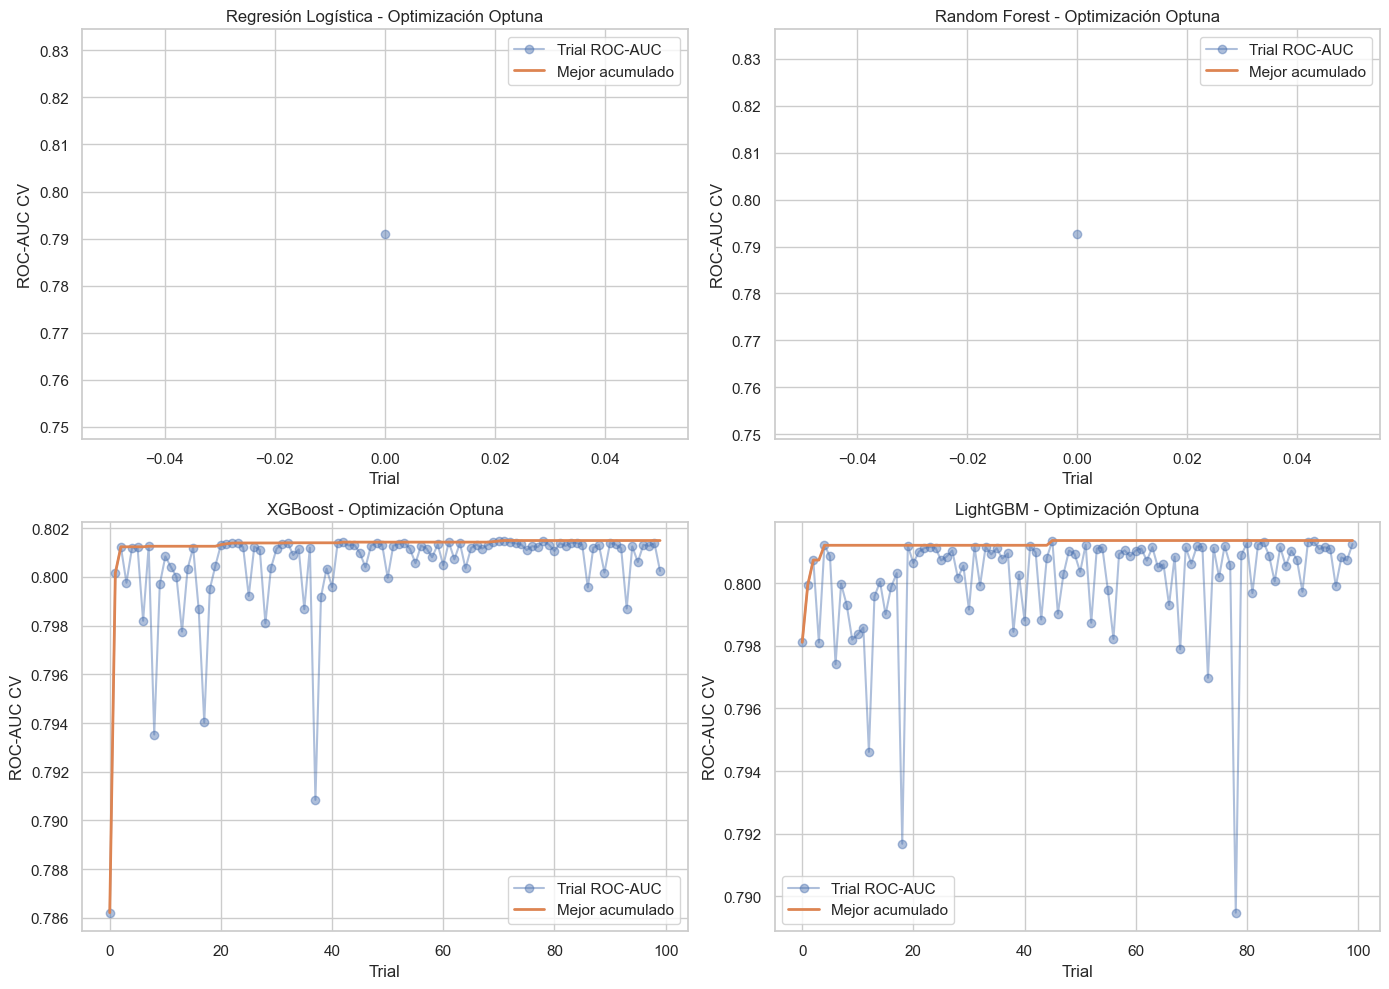

In [17]:
available_trials_models = [m for m in models if m in trials_data]

if not available_trials_models:
    print("No hay archivos de trials para graficar todavía.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, model in enumerate(models):
        ax = axes[i]
        model_label = MODEL_NAMES.get(model, model)

        if model not in trials_data:
            ax.set_title(f"{model_label} (sin datos)")
            ax.axis("off")
            continue

        df = trials_data[model].copy()
        df = df[df["state"] == "COMPLETE"].sort_values("number").reset_index(drop=True)

        if df.empty:
            ax.set_title(f"{model_label} (sin trials completos)")
            ax.axis("off")
            continue

        df["best_so_far"] = df["value"].cummax()

        ax.plot(df["number"], df["value"], marker="o", alpha=0.45, label="Trial ROC-AUC")
        ax.plot(df["number"], df["best_so_far"], linewidth=2.0, label="Mejor acumulado")
        ax.set_title(f"{model_label} - Optimización Optuna")
        ax.set_xlabel("Trial")
        ax.set_ylabel("ROC-AUC CV")
        ax.legend()

    plt.tight_layout()
    plt.show()

## 2) Comparación de Métricas de Validación

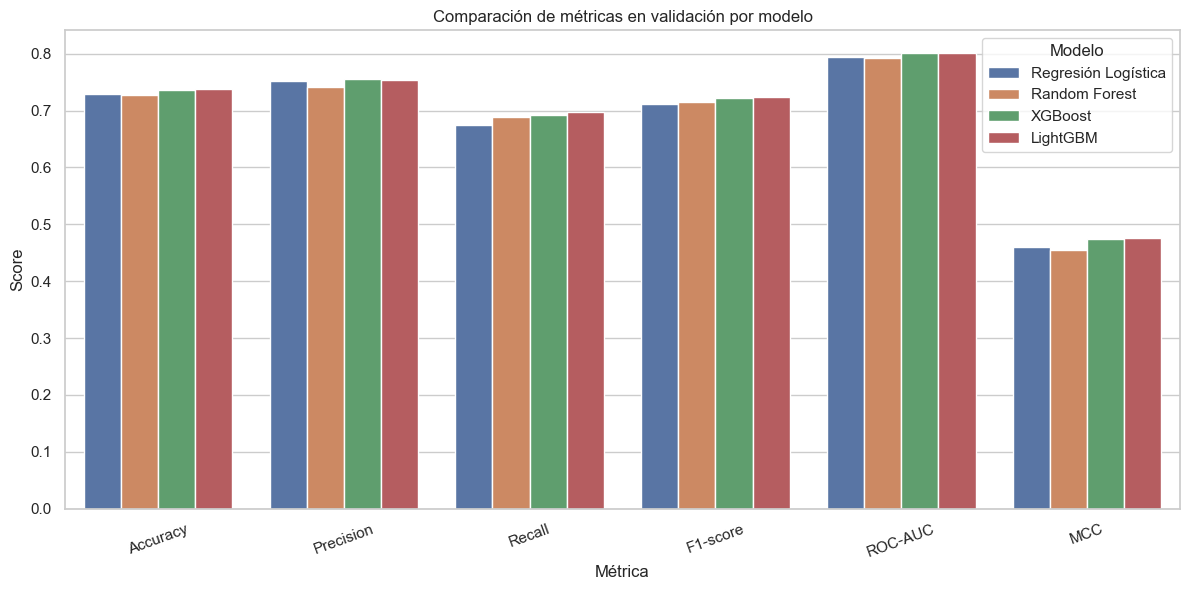

,model_name,Accuracy,Precision,Recall,F1-score,ROC-AUC,MCC
0,XGBoost,0.736219,0.754737,0.691678,0.721833,0.800925,0.473553
1,LightGBM,0.737354,0.753004,0.698231,0.724583,0.800621,0.475495
2,Regresión Logística,0.729086,0.751915,0.675295,0.711548,0.793457,0.459895
3,Random Forest,0.727464,0.742141,0.688401,0.714261,0.791883,0.455638


In [18]:
plot_columns = [
    "val_accuracy",
    "val_precision",
    "val_recall",
    "val_f1_score",
    "val_roc_auc",
    "val_mcc",
]

metric_labels = {
    "val_accuracy": "Accuracy",
    "val_precision": "Precision",
    "val_recall": "Recall",
    "val_f1_score": "F1-score",
    "val_roc_auc": "ROC-AUC",
    "val_mcc": "MCC",
}

if metrics_df.empty:
    print("No hay métricas de validación para comparar.")
else:
    available_plot_columns = [c for c in plot_columns if c in metrics_df.columns]

    if not available_plot_columns:
        print("No hay columnas de métricas de validación disponibles en metrics_df.")
    else:
        long_df = metrics_df.melt(
            id_vars=["model", "model_name"],
            value_vars=available_plot_columns,
            var_name="metric",
            value_name="score",
        )
        long_df["metric_label"] = long_df["metric"].map(metric_labels).fillna(long_df["metric"])

        plt.figure(figsize=(12, 6))
        sns.barplot(data=long_df, x="metric_label", y="score", hue="model_name")
        plt.title("Comparación de métricas en validación por modelo")
        plt.xlabel("Métrica")
        plt.ylabel("Score")
        plt.xticks(rotation=20)
        plt.legend(title="Modelo")
        plt.tight_layout()
        plt.show()

        ranking_col = "val_roc_auc" if "val_roc_auc" in metrics_df.columns else available_plot_columns[0]
        table_cols = ["model_name"] + available_plot_columns
        display(
            metrics_df[table_cols]
            .rename(columns=metric_labels)
            .sort_values(metric_labels.get(ranking_col, ranking_col), ascending=False)
            .reset_index(drop=True)
        )

## 3) Matriz de Confusión por Modelo

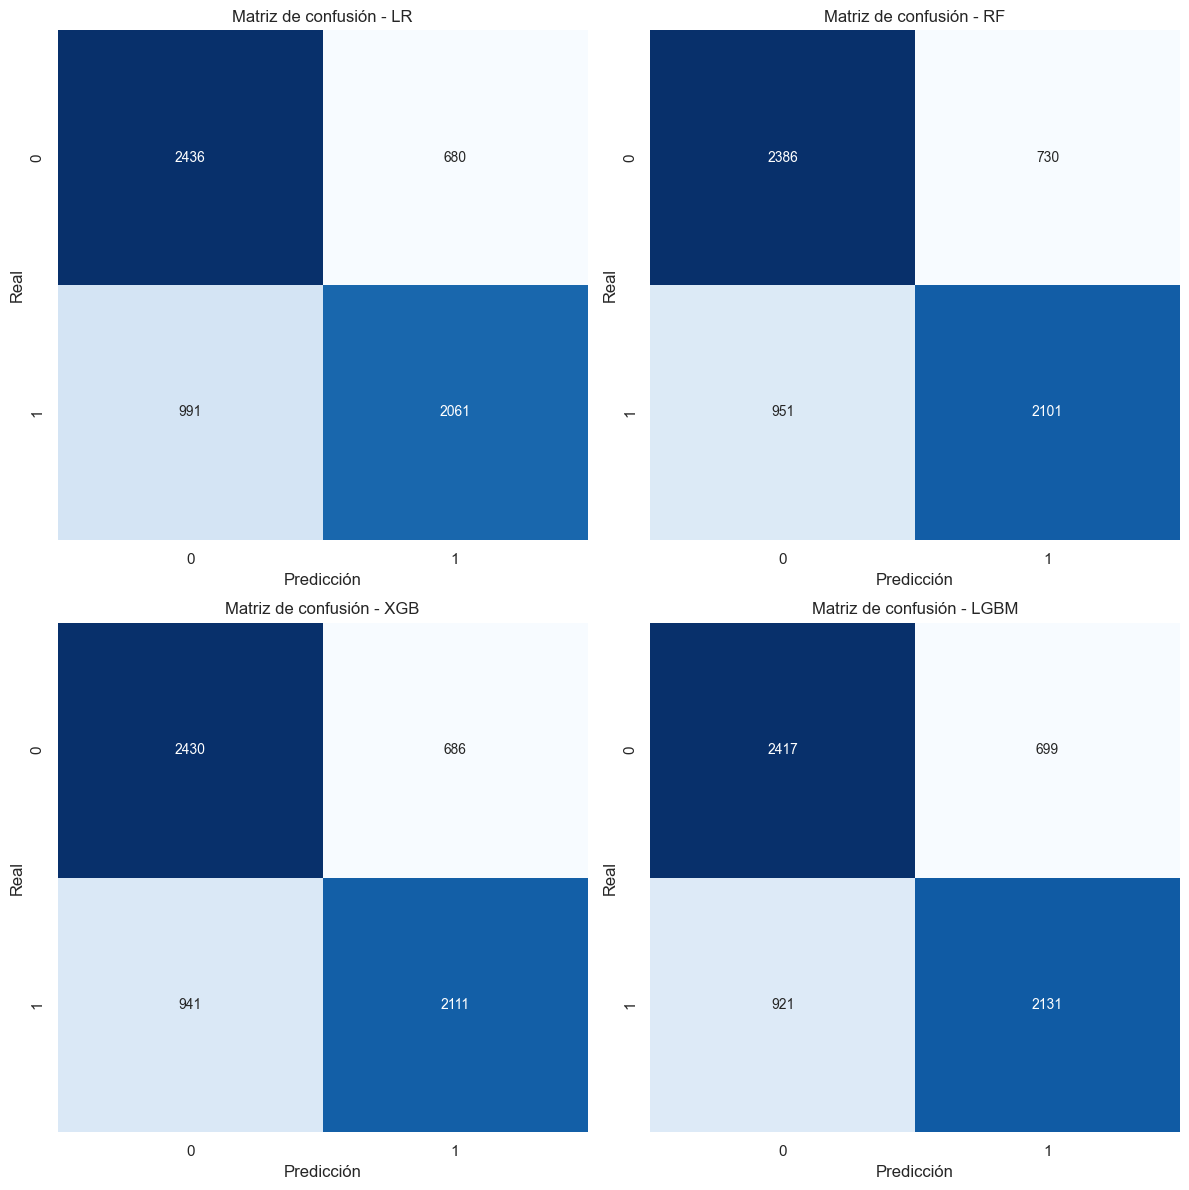

In [26]:
available_pred_models = [m for m in models if m in preds_data]

if not available_pred_models:
    print("No hay archivos de predicciones para graficar matrices de confusión.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()

    for i, model in enumerate(models):
        ax = axes[i]
        if model not in preds_data:
            ax.set_title(f"{model} (sin datos)")
            ax.axis("off")
            continue

        df = preds_data[model]
        cm = confusion_matrix(df["y_true"], df["y_pred"])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
        ax.set_title(f"Matriz de confusión - {model}")
        ax.set_xlabel("Predicción")
        ax.set_ylabel("Real")

    plt.tight_layout()
    plt.show()

## 4) Curvas ROC por Modelo

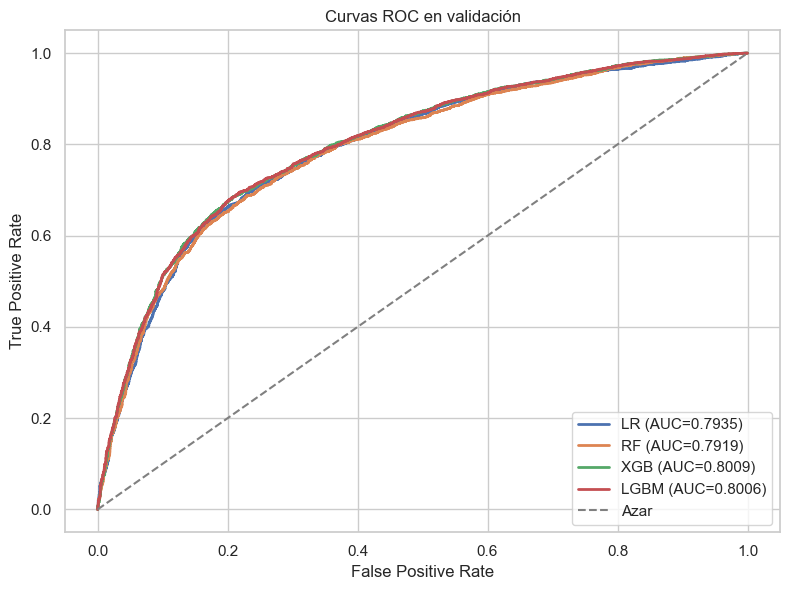

In [20]:
if not available_pred_models:
    print("No hay archivos de predicciones para graficar curvas ROC.")
else:
    plt.figure(figsize=(8, 6))

    for model in available_pred_models:
        df = preds_data[model]
        fpr, tpr, _ = roc_curve(df["y_true"], df["y_pred_proba"])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{model} (AUC={roc_auc:.4f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
    plt.title("Curvas ROC en validación")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

## 5) Ranking Final de Modelos

In [21]:
if metrics_df.empty:
    print("No hay métricas para construir el ranking de validación.")
else:
    ranking_cols = [
        c for c in ["model_name", "best_cv_roc_auc", "val_roc_auc", "val_f1_score", "val_mcc"]
        if c in metrics_df.columns
    ]

    if len(ranking_cols) <= 1:
        print("No hay suficientes columnas para construir el ranking de validación.")
    else:
        sort_col = "val_roc_auc" if "val_roc_auc" in ranking_cols else ranking_cols[-1]
        ranking_df = metrics_df[ranking_cols].sort_values(sort_col, ascending=False).reset_index(drop=True)
        display(
            ranking_df.rename(
                columns={
                    "model_name": "Modelo",
                    "best_cv_roc_auc": "Mejor ROC-AUC CV",
                    "val_roc_auc": "ROC-AUC Validación",
                    "val_f1_score": "F1-score Validación",
                    "val_mcc": "MCC Validación",
                }
            )
        )

,Modelo,Mejor ROC-AUC CV,ROC-AUC Validación,F1-score Validación,MCC Validación
0,XGBoost,0.801498,0.800925,0.721833,0.473553
1,LightGBM,0.801361,0.800621,0.724583,0.475495
2,Regresión Logística,0.790954,0.793457,0.711548,0.459895
3,Random Forest,0.792646,0.791883,0.714261,0.455638


In [22]:
TEST_INPUT_DIR = PROJECT_ROOT / "data" / "processed" / "model_inputs"

X_test = pd.read_csv(TEST_INPUT_DIR / "X_test.csv")
y_test = pd.read_csv(TEST_INPUT_DIR / "y_test.csv").values.ravel()

test_rows = []
for model in models:
    primary_model_path = MODELS_SOURCE_DIR / f"best_model_{model}.joblib"
    fallback_model_path = MODELS_DIR / f"best_model_{model}.joblib"

    model_path = primary_model_path if primary_model_path.exists() else fallback_model_path
    if not model_path.exists():
        print(
            f"No se encontró modelo para {model} en {primary_model_path} "
            f"ni en {fallback_model_path}."
        )
        continue

    clf = joblib.load(model_path)
    y_pred = clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else y_pred

    test_rows.append(
        {
            "model": model,
            "model_name": MODEL_NAMES.get(model, model),
            "test_accuracy": accuracy_score(y_test, y_pred),
            "test_precision": precision_score(y_test, y_pred, zero_division=0),
            "test_recall": recall_score(y_test, y_pred, zero_division=0),
            "test_f1_score": f1_score(y_test, y_pred, zero_division=0),
            "test_roc_auc": roc_auc_score(y_test, y_pred_proba),
            "test_mcc": matthews_corrcoef(y_test, y_pred),
        }
    )

if not test_rows:
    raise FileNotFoundError("No se pudieron cargar modelos para evaluar en test.")

test_metrics_df = (
    pd.DataFrame(test_rows)
    .sort_values("test_roc_auc", ascending=False)
    .reset_index(drop=True)
)

display(
    test_metrics_df[[
        "model_name",
        "test_accuracy",
        "test_precision",
        "test_recall",
        "test_f1_score",
        "test_roc_auc",
        "test_mcc",
    ]].rename(
        columns={
            "model_name": "Modelo",
            "test_accuracy": "Accuracy Test",
            "test_precision": "Precision Test",
            "test_recall": "Recall Test",
            "test_f1_score": "F1-score Test",
            "test_roc_auc": "ROC-AUC Test",
            "test_mcc": "MCC Test",
        }
    )
)

,Modelo,Accuracy Test,Precision Test,Recall Test,F1-score Test,ROC-AUC Test,MCC Test
0,LightGBM,0.735736,0.759868,0.681215,0.718395,0.805651,0.473350
1,XGBoost,0.734423,0.761746,0.674137,0.715269,0.804839,0.471232
2,Regresión Logística,0.737341,0.766143,0.675317,0.717868,0.796474,0.477292
3,Random Forest,0.729607,0.749513,0.681215,0.713734,0.795331,0.460531


## 6) Diagnóstico de Generalización (Validación vs Test)

Esta sección cuantifica la diferencia entre el rendimiento en validación y en test para evaluar estabilidad del modelo y posible sobreajuste.

In [23]:
if metrics_df.empty or "test_metrics_df" not in globals():
    print("No hay información suficiente para comparar validación vs test.")
else:
    val_cols = ["model", "model_name", "val_f1_score", "val_roc_auc", "val_mcc"]
    test_cols = ["model", "test_f1_score", "test_roc_auc", "test_mcc"]

    if not all(c in metrics_df.columns for c in val_cols):
        print("No se encuentran todas las columnas de validación requeridas.")
    elif not all(c in test_metrics_df.columns for c in test_cols):
        print("No se encuentran todas las columnas de test requeridas.")
    else:
        compare_df = (
            metrics_df[val_cols]
            .merge(test_metrics_df[test_cols], on="model", how="inner")
            .copy()
        )

        compare_df["delta_f1_abs"] = (compare_df["test_f1_score"] - compare_df["val_f1_score"]).abs()
        compare_df["delta_roc_auc_abs"] = (compare_df["test_roc_auc"] - compare_df["val_roc_auc"]).abs()
        compare_df["delta_mcc_abs"] = (compare_df["test_mcc"] - compare_df["val_mcc"]).abs()
        compare_df["delta_promedio_abs"] = compare_df[["delta_f1_abs", "delta_roc_auc_abs", "delta_mcc_abs"]].mean(axis=1)

        display(
            compare_df[[
                "model_name",
                "val_f1_score",
                "test_f1_score",
                "val_roc_auc",
                "test_roc_auc",
                "val_mcc",
                "test_mcc",
                "delta_promedio_abs",
            ]]
            .rename(
                columns={
                    "model_name": "Modelo",
                    "val_f1_score": "F1 Validación",
                    "test_f1_score": "F1 Test",
                    "val_roc_auc": "ROC-AUC Validación",
                    "test_roc_auc": "ROC-AUC Test",
                    "val_mcc": "MCC Validación",
                    "test_mcc": "MCC Test",
                    "delta_promedio_abs": "Brecha promedio abs.",
                }
            )
            .sort_values("Brecha promedio abs.")
            .reset_index(drop=True)
        )

,Modelo,F1 Validación,F1 Test,ROC-AUC Validación,ROC-AUC Test,MCC Validación,MCC Test,Brecha promedio abs.
0,Random Forest,0.714261,0.713734,0.791883,0.795331,0.455638,0.460531,0.002956
1,XGBoost,0.721833,0.715269,0.800925,0.804839,0.473553,0.471232,0.004266
2,LightGBM,0.724583,0.718395,0.800621,0.805651,0.475495,0.473350,0.004454
3,Regresión Logística,0.711548,0.717868,0.793457,0.796474,0.459895,0.477292,0.008911


## 7) Diagnóstico de Sobreajuste (Train vs Validación)

Esta sección usa los archivos overfitting_diagnostics_*.json para comparar métricas de entrenamiento vs validación e identificar riesgo de sobreajuste por modelo.

,Modelo,F1 Train,F1 Validación,Gap F1,ROC-AUC Train,ROC-AUC Validación,Gap ROC-AUC,Riesgo de sobreajuste
0,Random Forest,0.817329,0.714261,0.103067,0.924314,0.791883,0.132431,alto
1,LightGBM,0.730309,0.724583,0.005726,0.816069,0.800621,0.015448,bajo
2,XGBoost,0.726933,0.721833,0.005101,0.811645,0.800925,0.010719,bajo
3,Regresión Logística,0.711140,0.711548,-0.000408,0.791273,0.793457,-0.002184,bajo


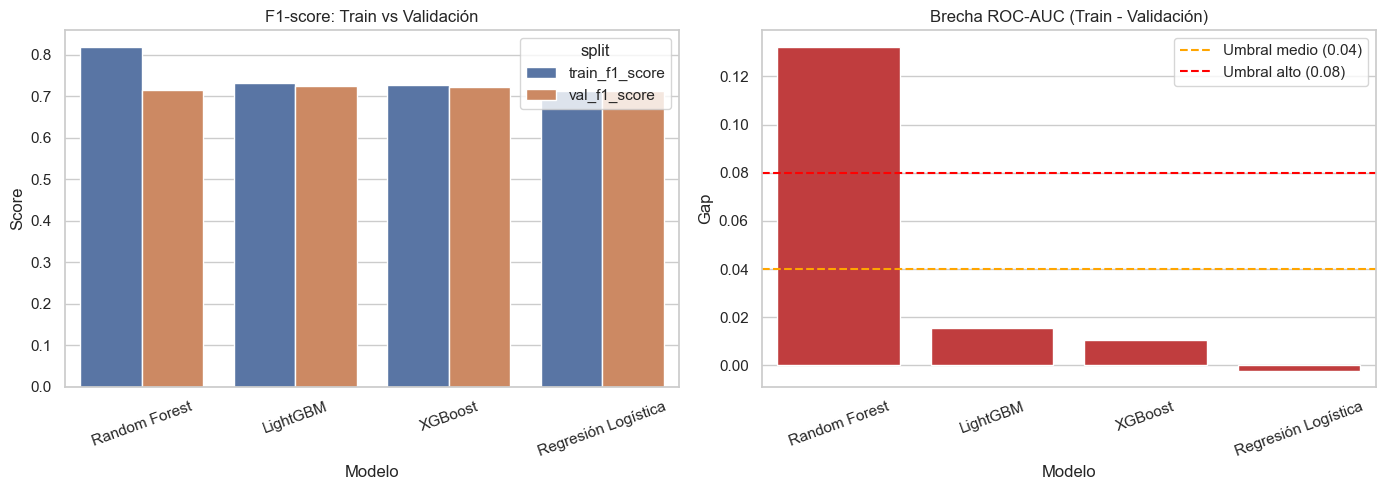

In [24]:
available_overfit_models = [m for m in models if m in overfit_data]

if not available_overfit_models:
    print("No hay archivos overfitting_diagnostics_*.json para visualizar.")
else:
    rows = []
    for model in available_overfit_models:
        d = overfit_data[model]
        rows.append({
            "model": model,
            "model_name": MODEL_NAMES.get(model, model),
            "train_f1_score": d.get("train_f1_score"),
            "val_f1_score": d.get("val_f1_score"),
            "gap_f1_score": d.get("gap_f1_score"),
            "train_roc_auc": d.get("train_roc_auc"),
            "val_roc_auc": d.get("val_roc_auc"),
            "gap_roc_auc": d.get("gap_roc_auc"),
            "overfitting_risk": d.get("overfitting_risk", "desconocido"),
        })

    overfit_df = pd.DataFrame(rows).sort_values("gap_roc_auc", ascending=False).reset_index(drop=True)
    display(
        overfit_df[[
            "model_name",
            "train_f1_score",
            "val_f1_score",
            "gap_f1_score",
            "train_roc_auc",
            "val_roc_auc",
            "gap_roc_auc",
            "overfitting_risk",
        ]].rename(columns={
            "model_name": "Modelo",
            "train_f1_score": "F1 Train",
            "val_f1_score": "F1 Validación",
            "gap_f1_score": "Gap F1",
            "train_roc_auc": "ROC-AUC Train",
            "val_roc_auc": "ROC-AUC Validación",
            "gap_roc_auc": "Gap ROC-AUC",
            "overfitting_risk": "Riesgo de sobreajuste",
        })
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    f1_long = overfit_df[["model_name", "train_f1_score", "val_f1_score"]].melt(
        id_vars="model_name",
        var_name="split",
        value_name="score",
    )
    sns.barplot(data=f1_long, x="model_name", y="score", hue="split", ax=axes[0])
    axes[0].set_title("F1-score: Train vs Validación")
    axes[0].set_xlabel("Modelo")
    axes[0].set_ylabel("Score")
    axes[0].tick_params(axis="x", rotation=20)

    sns.barplot(data=overfit_df, x="model_name", y="gap_roc_auc", ax=axes[1], color="#d62728")
    axes[1].set_title("Brecha ROC-AUC (Train - Validación)")
    axes[1].set_xlabel("Modelo")
    axes[1].set_ylabel("Gap")
    axes[1].tick_params(axis="x", rotation=20)
    axes[1].axhline(0.04, color="orange", linestyle="--", linewidth=1.5, label="Umbral medio (0.04)")
    axes[1].axhline(0.08, color="red", linestyle="--", linewidth=1.5, label="Umbral alto (0.08)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 8) Muestras Problemáticas en Validación

Esta sección resume los casos conflictivos detectados en problematic_validation_samples_*.csv, incluyendo errores de alta confianza y casos inciertos cerca del umbral de decisión.

,model,Modelo,Total de muestras problemáticas,Errores de alta confianza,Casos inciertos
0,LR,Regresión Logística,697,80,617
2,XGB,XGBoost,682,65,617
1,RF,Random Forest,681,64,617
3,LGBM,LightGBM,681,64,617


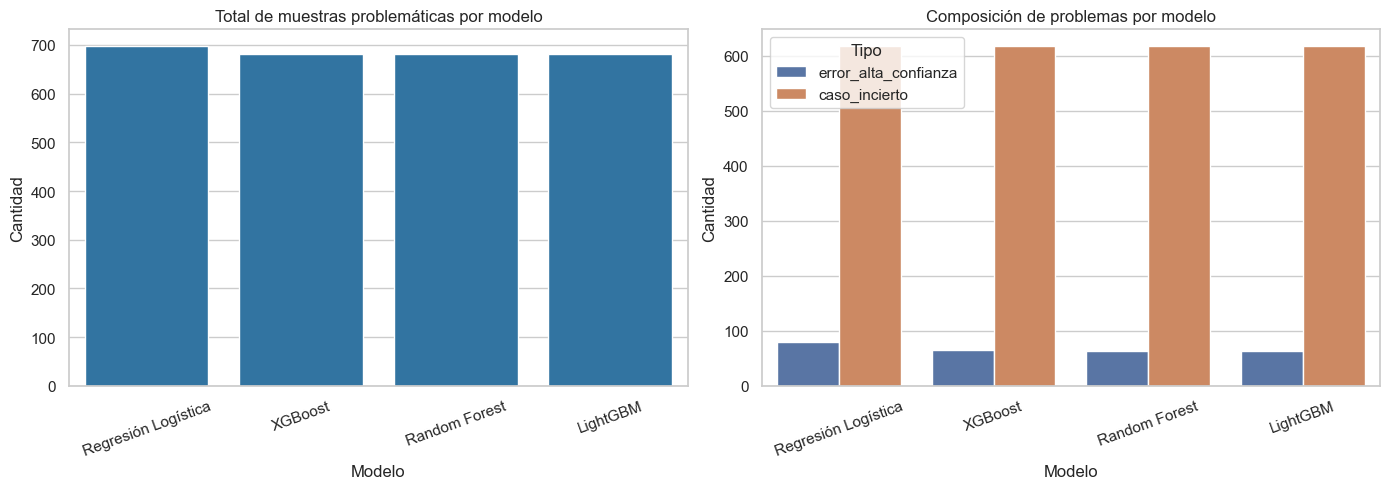

,model_name,row_id_val,problem_type,problem_score,y_true,y_pred,y_pred_proba,pred_confidence,uncertainty
0,Regresión Logística,1698,caso_incierto,0.999959,1,0,0.499980,0.500020,0.000020
1,Regresión Logística,811,caso_incierto,0.999895,1,1,0.500053,0.500053,0.000053
2,LightGBM,3208,caso_incierto,0.999835,0,0,0.499918,0.500082,0.000082
3,Regresión Logística,537,caso_incierto,0.999830,0,0,0.499915,0.500085,0.000085
4,Random Forest,4269,caso_incierto,0.999786,0,0,0.499893,0.500107,0.000107
5,Random Forest,5977,caso_incierto,0.999714,0,0,0.499857,0.500143,0.000143
6,LightGBM,2654,caso_incierto,0.999712,0,0,0.499856,0.500144,0.000144
7,LightGBM,5081,caso_incierto,0.999685,0,1,0.500158,0.500158,0.000158
8,XGBoost,4954,caso_incierto,0.999684,0,1,0.500158,0.500158,0.000158
9,Regresión Logística,3406,caso_incierto,0.999599,0,0,0.499800,0.500200,0.000200


In [25]:
available_problem_models = [m for m in models if m in problematic_data]

if not available_problem_models:
    print("No hay archivos problematic_validation_samples_*.csv para visualizar.")
else:
    summary_rows = []
    for model in available_problem_models:
        pdf = problematic_data[model].copy()
        if pdf.empty:
            summary_rows.append({
                "model": model,
                "model_name": MODEL_NAMES.get(model, model),
                "total_problematic": 0,
                "error_alta_confianza": 0,
                "caso_incierto": 0,
            })
            continue

        type_counts = pdf["problem_type"].value_counts()
        summary_rows.append({
            "model": model,
            "model_name": MODEL_NAMES.get(model, model),
            "total_problematic": len(pdf),
            "error_alta_confianza": int(type_counts.get("error_alta_confianza", 0)),
            "caso_incierto": int(type_counts.get("caso_incierto", 0)),
        })

    problem_summary_df = pd.DataFrame(summary_rows).sort_values("total_problematic", ascending=False)
    display(
        problem_summary_df.rename(columns={
            "model_name": "Modelo",
            "total_problematic": "Total de muestras problemáticas",
            "error_alta_confianza": "Errores de alta confianza",
            "caso_incierto": "Casos inciertos",
        })
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(data=problem_summary_df, x="model_name", y="total_problematic", ax=axes[0], color="#1f77b4")
    axes[0].set_title("Total de muestras problemáticas por modelo")
    axes[0].set_xlabel("Modelo")
    axes[0].set_ylabel("Cantidad")
    axes[0].tick_params(axis="x", rotation=20)

    long_problem = problem_summary_df.melt(
        id_vars=["model_name"],
        value_vars=["error_alta_confianza", "caso_incierto"],
        var_name="tipo",
        value_name="cantidad",
    )
    sns.barplot(data=long_problem, x="model_name", y="cantidad", hue="tipo", ax=axes[1])
    axes[1].set_title("Composición de problemas por modelo")
    axes[1].set_xlabel("Modelo")
    axes[1].set_ylabel("Cantidad")
    axes[1].tick_params(axis="x", rotation=20)
    axes[1].legend(title="Tipo")

    plt.tight_layout()
    plt.show()

    top_rows = []
    for model in available_problem_models:
        pdf = problematic_data[model].copy()
        if pdf.empty or "problem_score" not in pdf.columns:
            continue
        pdf["model_name"] = MODEL_NAMES.get(model, model)
        top_rows.append(pdf.sort_values("problem_score", ascending=False).head(10))

    if top_rows:
        top_problematic_df = pd.concat(top_rows, ignore_index=True)
        cols = [c for c in ["model_name", "row_id_val", "problem_type", "problem_score", "y_true", "y_pred", "y_pred_proba", "pred_confidence", "uncertainty"] if c in top_problematic_df.columns]
        display(
            top_problematic_df[cols]
            .sort_values(["problem_score"], ascending=False)
            .reset_index(drop=True)
        )